In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#display setting
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## Load Dataset

In [16]:
#replace with your dataset path
df = pd.read_csv('membership.csv', encoding='latin1')
df

,member_id,plan_id,start_date,end_date,pcp_provider_id
0,M00001,PlanC,2023-01-25,2025-08-17,P0016
1,M00002,PlanA,2023-01-16,2025-08-08,P0006
2,M00003,PlanA,2023-01-03,2025-08-04,P0017
3,M00004,PlanB,2023-01-07,2025-08-06,P0027
4,M00005,PlanA,2023-01-02,2025-08-08,P0050
...,...,...,...,...,...
495,M00496,PlanC,2023-01-31,2025-08-15,P0047
496,M00497,PlanA,2023-01-27,2025-08-15,P0049
497,M00498,PlanA,2023-01-20,2025-08-03,P0037
498,M00499,PlanB,2023-01-22,2025-08-04,P0042


## Data Cleaning

In [11]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 member_id          0
plan_id            0
start_date         0
end_date           0
pcp_provider_id    0
dtype: int64


In [12]:
# Drop duplicates if any
df.drop_duplicates(inplace=True)

In [13]:
# Data types
print("Data types:\n", df.dtypes)

Data types:
 member_id          object
plan_id            object
start_date         object
end_date           object
pcp_provider_id    object
dtype: object


## Descriptive Statistics

In [14]:
# Summary statistics
df.describe()

,member_id,plan_id,start_date,end_date,pcp_provider_id
count,500,500,500,500,500
unique,500,3,31,31,50
top,M00001,PlanA,2023-01-27,2025-08-04,P0016
freq,1,174,27,26,17


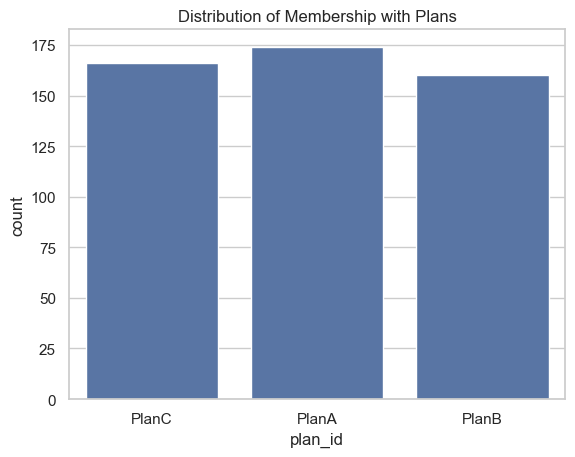

In [18]:
# Example target variable 'Outcome' (0 = No Diabetes, 1 = Diabetes)
sns.countplot(x='plan_id', data=df)
plt.title("Distribution of Membership with Plans")
plt.show()

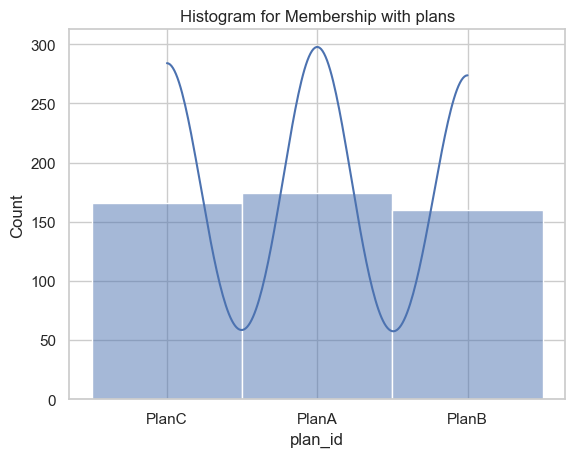

In [22]:
# Histogram for Age
sns.histplot(df['plan_id'], kde=True, bins=20)
plt.title("Histogram for Membership with plans")
plt.show()

In [27]:
from ydata_profiling import ProfileReport

# Generate profiling report
profile = ProfileReport(df, title="Membership Data Profiling Report", explorative=True)

# Save to HTML
profile.to_file("Membership_profile_report.html")

print("✅ Profiling report generated: Membership_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 64.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Profiling report generated: Membership_profile_report.html


In [29]:
profile

## Export to Excel

In [30]:
# 1. Basic summary statistics
summary = df.describe(include='all').transpose()
summary

,count,unique,top,freq
member_id,500,500,M00001,1
plan_id,500,3,PlanA,174
start_date,500,31,2023-01-27,27
end_date,500,31,2025-08-04,26
pcp_provider_id,500,50,P0016,17


In [31]:
# 2. Missing values
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'MissingValues']
missing

,Column,MissingValues
0,member_id,0
1,plan_id,0
2,start_date,0
3,end_date,0
4,pcp_provider_id,0


In [34]:
# 4. Export all to Excel
with pd.ExcelWriter("membership_eda_summary.xlsx") as writer:
    summary.to_excel(writer, sheet_name="Summary Stats")
    missing.to_excel(writer, sheet_name="Missing Values", index=False)
    correlation.to_excel(writer, sheet_name="Correlations")
print("✅ EDA results saved to membership_eda_summary.xlsx")

✅ EDA results saved to membership_eda_summary.xlsx


## Export to folder

In [35]:
# 1. Summary statistics
summary = df.describe(include='all').transpose().reset_index()
summary['Section'] = "Summary Stats"

In [36]:
# 2. Missing values
missing = df.isnull().sum().reset_index()
missing.columns = ['index', 'MissingValues']
missing['Section'] = "Missing Values"

In [37]:
# 3. Correlation matrix (flattened)
corr = df.corr(numeric_only=True).stack().reset_index()
corr.columns = ['Var1', 'Var2', 'Correlation']
corr['Section'] = "Correlations"

In [38]:
# Combine all
combined = pd.concat([summary, missing, corr], axis=0, ignore_index=True)

In [39]:
# Save to folder path
output_path = "output/Membership_eda_results.csv"
import os
os.makedirs("output", exist_ok=True)
combined.to_csv(output_path, index=False)
print(f"✅ File saved at: {output_path}")
r"C:\Users\israe\Documents\PYTHON TRAINING\Output\Membership_eda_results.csv"

✅ File saved at: output/Membership_eda_results.csv


'C:\\Users\\israe\\Documents\\PYTHON TRAINING\\Output\\Membership_eda_results.csv'

## Export to zip file

In [41]:
import os
import zipfile
import pandas as pd
from datetime import datetime

# Paths
date_str = datetime.today().strftime("%Y-%m-%d")
zip_file = f"output/archive/Membership_results_{date_str}.zip"
csv_name = f"EmadeStore_results_{date_str}.csv"  # name inside the zip

# Ensure folder exists
os.makedirs(os.path.dirname(zip_file), exist_ok=True)

# Write CSV directly into zip
with zipfile.ZipFile(zip_file, mode="w", compression=zipfile.ZIP_DEFLATED) as zf:
    with zf.open(csv_name, mode="w") as f:
        df.to_csv(f, index=False)

print(f"CSV saved inside {zip_file}")


CSV saved inside output/archive/Membership_results_2025-09-03.zip
